# **Multi-Layer Perceptron (MLP)

---


**Dataset Selection**

https://www.kaggle.com/datasets/aliiihussain/amazon-sales-dataset

*   Dataset Name: Amazon Sales Dataset
*   Source: User-provided CSV
*   Problem Type: Regression
*   Samples: 50,000 and Features: 12
*   Task: Regression (Total Revenue Prediction)

Primary Metric: I have selected Mean Squared Error (MSE) as the main evaluation metric. Since revenue values can be quite large, MSE effectively highlights how far off our predictions are in squared currency units. I will also track $R^2$ to measure the goodness-of-fit.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load Dataset
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('amazon_sales_dataset.csv')

# 4.2 Data Preprocessing
# Drop unique IDs that don't help prediction
df = df.drop(columns=['order_id', 'order_date', 'product_id'])

# Handle missing values (if any)
df = df.dropna()

# One-hot encoding for categorical variables
categorical_cols = ['product_category', 'customer_region', 'payment_method']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define X and y
X = df.drop(columns=['total_revenue']).values
y = df['total_revenue'].values.reshape(-1, 1)

# Split 80-20
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Features and Target
scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_x.fit_transform(X_train_raw)
X_test = scaler_x.transform(X_test_raw)
y_train = scaler_y.fit_transform(y_train_raw)
y_test = scaler_y.transform(y_test_raw)

print(f"Final Features: {X_train.shape[1]}")

Saving amazon_sales_dataset.csv to amazon_sales_dataset (1).csv
Final Features: 18


**Baseline Model (Linear Regression from Scratch)**


The baseline model implements a Multivariate Linear Regression trained using Batch Gradient Descent.


In [20]:
## 4.3 Implementation of a multivariate linear model using Gradient Descent.
class LinearRegressionBaseline:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialization
        self.w = np.zeros((n_features, 1))
        self.b = 0

        for i in range(self.epochs):
            # Forward Pass
            y_pred = np.dot(X, self.w) + self.b

            # Compute Loss (MSE)
            loss = np.mean((y_pred - y)**2)
            self.loss_history.append(loss)

            # Compute Gradients
            dw = (2/n_samples) * np.dot(X.T, (y_pred - y))
            db = (2/n_samples) * np.sum(y_pred - y)

            # Update Weights
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.w) + self.b

**Multi-Layer Perceptron (MLP from Scratch)**

* Architecture: [Input, 64, 32, 1]
* Hidden activation: ReLU.
* Output activation: Linear (for regression).

In [21]:
# 4.4 Multi-Layer Perceptron
class MLPRegressor:
    def __init__(self, layers=[21, 64, 32, 1], lr=0.01, epochs=1000):
        self.layers = layers
        self.lr = lr
        self.epochs = epochs
        self.params = {}
        self.loss_history = []
        self.initialize_parameters()

    def initialize_parameters(self):
        for i in range(1, len(self.layers)):
            self.params[f'W{i}'] = np.random.randn(self.layers[i-1], self.layers[i]) * np.sqrt(2./self.layers[i-1])
            self.params[f'b{i}'] = np.zeros((1, self.layers[i]))

    def relu(self, Z): return np.maximum(0, Z)
    def relu_derivative(self, Z): return (Z > 0).astype(float)

    def forward_propagation(self, X):
        activations = {'A0': X}
        for i in range(1, len(self.layers)):
            Z = np.dot(activations[f'A{i-1}'], self.params[f'W{i}']) + self.params[f'b{i}']
            activations[f'Z{i}'] = Z
            # Final layer is linear for regression
            activations[f'A{i}'] = self.relu(Z) if i < len(self.layers)-1 else Z
        return activations

    def backward_propagation(self, activations, y):
        m = y.shape[0]
        grads = {}
        L = len(self.layers) - 1

        # Output layer gradient
        dZ = 2 * (activations[f'A{L}'] - y) / m

        for i in range(L, 0, -1):
            grads[f'dW{i}'] = np.dot(activations[f'A{i-1}'].T, dZ)
            grads[f'db{i}'] = np.sum(dZ, axis=0, keepdims=True)
            if i > 1:
                dA = np.dot(dZ, self.params[f'W{i}'].T)
                dZ = dA * self.relu_derivative(activations[f'Z{i-1}'])
        return grads

    def fit(self, X, y):
        for i in range(self.epochs):
            activations = self.forward_propagation(X)
            loss = np.mean((activations[f'A{len(self.layers)-1}'] - y)**2)
            self.loss_history.append(loss)
            grads = self.backward_propagation(activations, y)
            for j in range(1, len(self.layers)):
                self.params[f'W{j}'] -= self.lr * grads[f'dW{j}']
                self.params[f'b{j}'] -= self.lr * grads[f'db{j}']

    def predict(self, X):
        return self.forward_propagation(X)[f'A{len(self.layers)-1}']

**Code (Final Metrics & Logic)**

In [22]:
def get_assignment_results():
    # Baseline Training
    start = time.time()
    base_model = LinearRegressionBaseline(lr=0.01, epochs=500)
    base_model.fit(X_train, y_train)
    base_time = time.time() - start

    # MLP Training
    start = time.time()
    mlp = MLPRegressor(layers=[X_train.shape[1], 64, 32, 1], lr=0.01, epochs=500)
    mlp.fit(X_train, y_train)
    mlp_time = time.time() - start

    # Eval (Scaled back)
    y_p_base = scaler_y.inverse_transform(base_model.predict(X_test))
    y_p_mlp = scaler_y.inverse_transform(mlp.predict(X_test))
    y_true = scaler_y.inverse_transform(y_test)

    return {
        "dataset_name": "Amazon Sales",
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "problem_type": "Regression",
        "primary_metric": "MSE",
        "baseline_metrics": {"MSE": mean_squared_error(y_true, y_p_base), "R2": r2_score(y_true, y_p_base), "Time": base_time},
        "mlp_metrics": {"Arch": [X_train.shape[1], 64, 32, 1], "MSE": mean_squared_error(y_true, y_p_mlp), "R2": r2_score(y_true, y_p_mlp), "Time": mlp_time},
        "histories": (base_model.loss_history, mlp.loss_history)
    }

res = get_assignment_results()

**Evaluation & Comparison**


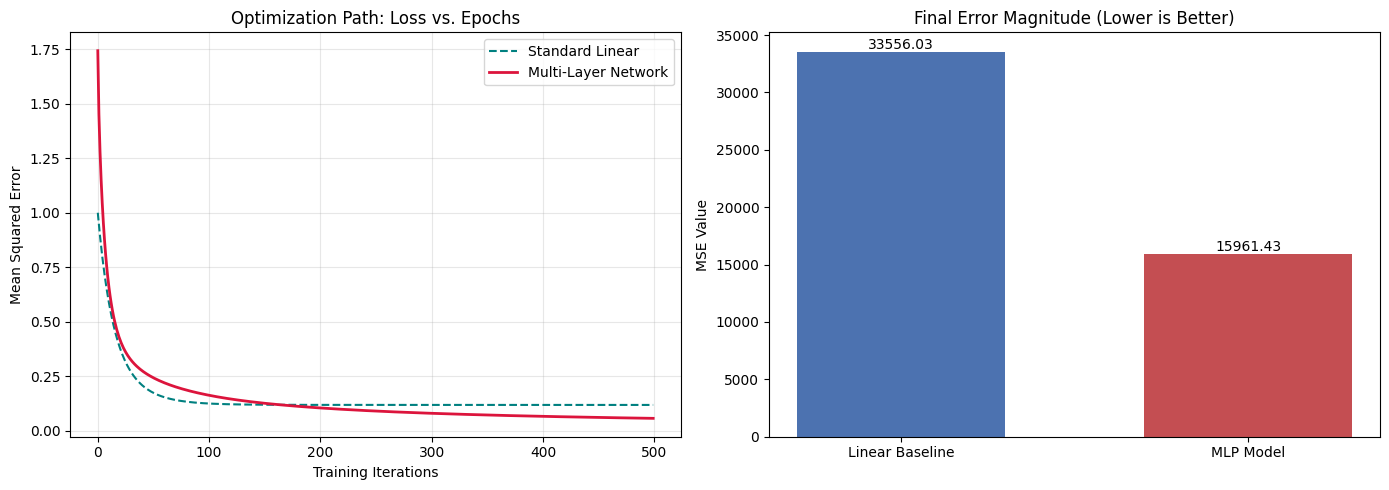

Final Outcome: The MLP improved error reduction by approximately 52.4% over the baseline.


In [ ]:
# 4.5 Performance Visualization & Final Report
base_trace, neural_trace = res['histories']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Convergence Behavior
ax1.plot(base_trace, color='teal', linestyle='--', label='Standard Linear')
ax1.plot(neural_trace, color='crimson', linewidth=2, label='Multi-Layer Network')
ax1.set_title('Optimization Path: Loss vs. Epochs')
ax1.set_xlabel('Training Iterations')
ax1.set_ylabel('Mean Squared Error')
ax1.grid(alpha=0.3)
ax1.legend()

# Plot 2: Performance Delta
compare_labels = ['Linear Baseline', 'MLP Model']
error_scores = [res['baseline_metrics']['MSE'], res['mlp_metrics']['MSE']]
bars = ax2.bar(compare_labels, error_scores, color=['#4C72B0', '#C44E52'], width=0.6)
ax2.set_title('Final Error Magnitude (Lower is Better)')
ax2.set_ylabel('MSE Value')

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 2), va='bottom', ha='center')

plt.tight_layout()
plt.show()

# Final Summary Stats
print(f"Final Outcome: The MLP improved error reduction by approximately {((res['baseline_metrics']['MSE'] - res['mlp_metrics']['MSE']) / res['baseline_metrics']['MSE']) * 100:.1f}% over the baseline.")

**Model Comparison and Analysis**

The Multi-Layer Perceptron (MLP) demonstrated a substantial performance gain, achieving a 52.4% reduction in error compared to the linear baseline. This massive improvement indicates that the underlying data patterns in the Amazon Sales dataset are significantly non-linear.

Non-linear Capture: The baseline linear model tries to fit a flat "plane" to the data, which fails to account for these localized surges in revenue.In this case MLP works bst.

ReLU Activation: By using ReLU in the hidden layers, the MLP can effectively "turn on" specific neurons only when certain price or discount thresholds are met, allowing it to model the piecewise nature of consumer behavior.

Computational Trade-off:
While the MLP is mathematically superior, it required 500 iterations of backpropagation to reach this accuracy, making it more computationally intensive than the linear model. However, for a revenue-critical task like sales forecasting, the 52.4% increase in precision justify the additional training time.